# 03. Modeling — 학습·평가·모델 선택 과정

- 최종 파이프라인 코드는 `src/train.py`, 검증 실험 코드는 `experiments/`에 있다
- 이 노트북은 **결과를 모아 보고 해석**하는 곳이다. 실험(반복 Hold-out 등)은 오래 걸려서 저장된 결과(`results/*.csv`)를 읽는다
- 흐름: ① 최종 파이프라인 실행 → ② DAY1 후보 비교 → ③ 분할 누수 점검 → ④ 모델 선택(반복 Hold-out) → ⑤ 후보 밖 모델·넓은 튜닝 → ⑥ 진단(외삽) → ⑦ 오류 분석(Batch2)

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
RES = ROOT / 'results'
plt.rcParams.update({'font.family': ['AppleGothic', 'Noto Sans CJK JP', 'sans-serif'], 'axes.unicode_minus': False})
pd.set_option('display.width', 200)

## ① 최종 파이프라인 실행 (`src/train.py`)

- 분할: Batch1을 **충전 정책 단위**로 Train 80% / Valid 20% (같은 정책 셀이 양쪽에 들어가면 누수)
- 튜닝: Train 안에서 정책 단위 5-fold CV
- 후보 4개(DAY1 전략)를 모두 학습하고, 최종 모델 성능을 과제 포맷으로 저장

In [2]:
from src.train import main, FINAL_MODEL
perf = main()   # 약 30초

Train 29셀(16정책) / Valid 7셀(4정책) / Test B2 39셀, B3 44셀
  Baseline (Variance)    Train 9.2% | Valid 8.1% | Test 29.6% | Test 12.2%


  ElasticNet             Train 9.8% | Valid 11.1% | Test 32.4% | Test 12.3%


  LightGBM               Train 10.2% | Valid 15.1% | Test 33.4% | Test 19.6%
  Voting (EN+LGBM)       Train 9.2% | Valid 13.1% | Test 32.8% | Test 16.0%

ElasticNet best: {'elasticnet__alpha': np.float64(0.021544346900318822), 'elasticnet__l1_ratio': 0.3}
ElasticNet 계수 (표준화 기준):
 dQ_log_var          -0.0404
dQ_log_min          -0.0096
chargetime_mean_5    0.0035
QD_slope_91_100      0.0002
dQ_skew             -0.0000
dQ_at_2V             0.0000
LightGBM best: {'learning_rate': 0.03, 'min_child_samples': 3, 'n_estimators': 100, 'num_leaves': 4}

=== 최종 모델: Baseline (Variance) ===
                  split  MAPE(%)  RMSE(cycle)                                note
      Train (Batch1 CV)     9.17        94.23                  정책 단위 5-fold CV 평균
Valid (Batch1 Hold-out)     8.09        83.87                  정책 단위 Hold-out 20%
          Test (Batch2)    29.62       168.04                               최종 평가
      Gap (Train-Valid)    -1.08          NaN         Valid−Train 오차, (+): 과적합 의심
    

## ② DAY1 후보 4개 비교 (같은 분할 1회)

In [3]:
allp = pd.read_csv(RES / 'model_performance_all.csv')
keep = ['Train (Batch1 CV)', 'Valid (Batch1 Hold-out)', 'Test (Batch2)', 'Test (Batch3)']
allp[allp.split.isin(keep)].pivot(index='model', columns='split', values='MAPE(%)')[keep].round(2)

split,Train (Batch1 CV),Valid (Batch1 Hold-out),Test (Batch2),Test (Batch3)
model,,,,
Baseline (Variance),9.17,8.09,29.62,12.16
ElasticNet,9.78,11.10,32.37,12.34
LightGBM,10.19,15.12,33.42,19.55
Voting (EN+LGBM),9.22,13.13,32.79,15.97


- DAY1 전략은 "ElasticNet(외삽) + LightGBM(비선형) Voting"이었지만, **가장 단순한 Baseline(`dQ_log_var` 1개 선형회귀)이 Valid에서 가장 좋음**
- 단, 분할 1회 결과는 운에 따라 ±2%p 흔들리므로 ④에서 반복 검증

## ③ 분할 누수 점검 (`experiments/split_leakage_check.py`)
처음엔 셀 단위 무작위 분할 → Valid 8셀 중 5셀이 같은 정책의 짝 셀을 Train에 두고 있었다. seed 30회로 효과 크기를 확인

In [4]:
leak = pd.read_csv(RES / 'split_leakage_check.csv')
leak.groupby(['model', 'split']).agg(valid_mape=('valid_mape', 'mean'), std=('valid_mape', 'std'),
                                     leak_ratio=('valid_leak_ratio', 'mean')).round(2)

valid_mape   std  leak_ratio
model      split                               
Baseline   policy        9.19  2.44         0.0
           random        8.50  1.77         0.7
ElasticNet policy       10.06  2.13         0.0
           random        9.52  1.71         0.7

- 무작위 분할은 Valid를 **0.5~0.7%p 낙관적**으로 보이게 함 → 정책 단위 분할로 수정
- 분할 운에 따른 흔들림(표준편차 약 2%p)이 누수 효과보다 큼 → Valid 숫자 하나로 모델 순위를 정하면 위험

## ④ 최종 모델 선택 (`experiments/model_selection.py`)
Test는 보지 않고 Batch1 안에서만 결정. 정책 단위 Hold-out × 20회, 매번 Train에서 튜닝

,평균,표준편차,1등 횟수
model,,,
Baseline (Variance),9.55,2.56,14.0
ElasticNet,11.11,2.13,5.0
Voting (EN+LGBM),12.15,2.67,0.0
LightGBM,13.67,3.98,1.0


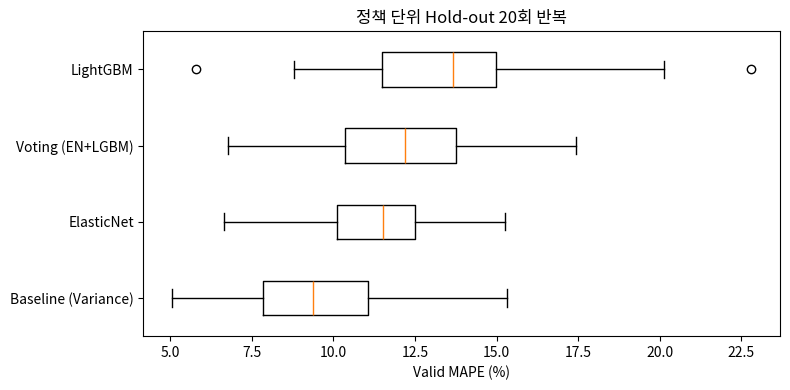

In [5]:
sel = pd.read_csv(RES / 'model_selection_repeated_holdout.csv')
wide = sel.pivot(index='seed', columns='model', values='valid_mape')
order = wide.mean().sort_values().index
summary = pd.DataFrame({'평균': wide.mean(), '표준편차': wide.std(),
                        '1등 횟수': wide.idxmin(axis=1).value_counts()}).reindex(order).fillna(0)
display(summary.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([wide[m] for m in order], labels=order, vert=False)
ax.set(xlabel='Valid MAPE (%)', title='정책 단위 Hold-out 20회 반복')
plt.tight_layout(); plt.show()

- **최종 모델 = Baseline** (평균 9.55%, 20회 중 14회 1등)
- 이유: Train 29셀 + 강한 단일 신호(r = −0.84) → 피처·모델을 복잡하게 할수록 정보보다 흔들림이 커짐 (편향-분산 트레이드오프)

## ⑤ 후보 밖 모델 + 넓은 하이퍼파라미터 탐색
"튜닝을 덜 해서 진 것 아닌가?"를 확인 (`experiments/model_zoo.py`, `experiments/tuning_deep.py`)

In [6]:
display(pd.read_csv(RES / 'model_zoo_summary.csv', index_col=0))
display(pd.read_csv(RES / 'tuning_deep_summary.csv', index_col=0))

,Valid 평균,표준편차,Baseline보다 나은 횟수,(참고) Test B2,(참고) Test B3,(참고) B3 예측 최대
model,,,,,,
"Baseline (선형, dQ_log_var 1개)",9.55,2.56,0,29.62,12.16,1669.62
Lasso,10.82,2.16,6,31.38,12.46,1524.13
RandomForest,11.89,3.21,5,34.60,18.99,869.96
XGBoost,12.82,3.29,3,34.11,18.99,911.59
Gaussian Process,12.91,3.00,3,33.04,13.29,1457.24
Ridge,14.02,3.52,3,34.05,14.15,1326.04
KNN,14.39,2.94,1,44.80,18.39,883.63
SVR (RBF),14.99,5.10,3,35.76,20.89,902.24
Huber,15.11,5.16,3,31.96,11.09,1574.36


,CV점수,Valid평균,Valid표준편차,낙관 정도(Valid−CV),Baseline보다 나은 횟수
model,,,,,
Baseline,8.99,9.45,2.24,0.46,0
ElasticNet (넓은 탐색),9.84,10.95,1.91,1.11,2
RandomForest (넓은 탐색),10.72,11.98,3.86,1.25,2
XGBoost (넓은 탐색),11.06,13.19,3.78,2.13,2
LightGBM (넓은 탐색),11.17,13.37,3.66,2.21,1
SVR (넓은 탐색),10.17,16.40,4.88,6.23,0


- 모델 10개, 넓은 탐색(모델당 40조합) 모두 Valid에서 Baseline을 넘지 못함
- 규제 없는 6피처 선형은 표준편차 10.5 → 다중공선성으로 극도로 불안정. Lasso(피처를 지움) > Ridge(피처를 다 남김)
- 튜닝을 많이 할수록 CV 점수가 실제보다 좋아 보이는 착시가 커짐 (SVR: CV 10.2% → Valid 16.4%)
- (참고) Test에서 Huber가 Batch3 11.1%로 가장 좋았지만, Test로 모델을 고르면 누수라 선택에 반영하지 않음

## ⑥ 진단 — 외삽 (`experiments/model_diagnostics.py`)

,batch,model,실제_min,실제_max,예측_min,예측_max,실제>Train최대(셀),예측>Train최대(셀),실제<Train최소(셀),예측<Train최소(셀)
0,b2,ElasticNet,392.0,1186.0,491.2,1094.3,2,2,30,3
1,b2,LightGBM,392.0,1186.0,576.0,858.8,2,0,30,0
2,b3,ElasticNet,541.0,1935.0,634.1,1365.9,17,9,0,0
3,b3,LightGBM,541.0,1935.0,578.6,895.3,17,0,0,0


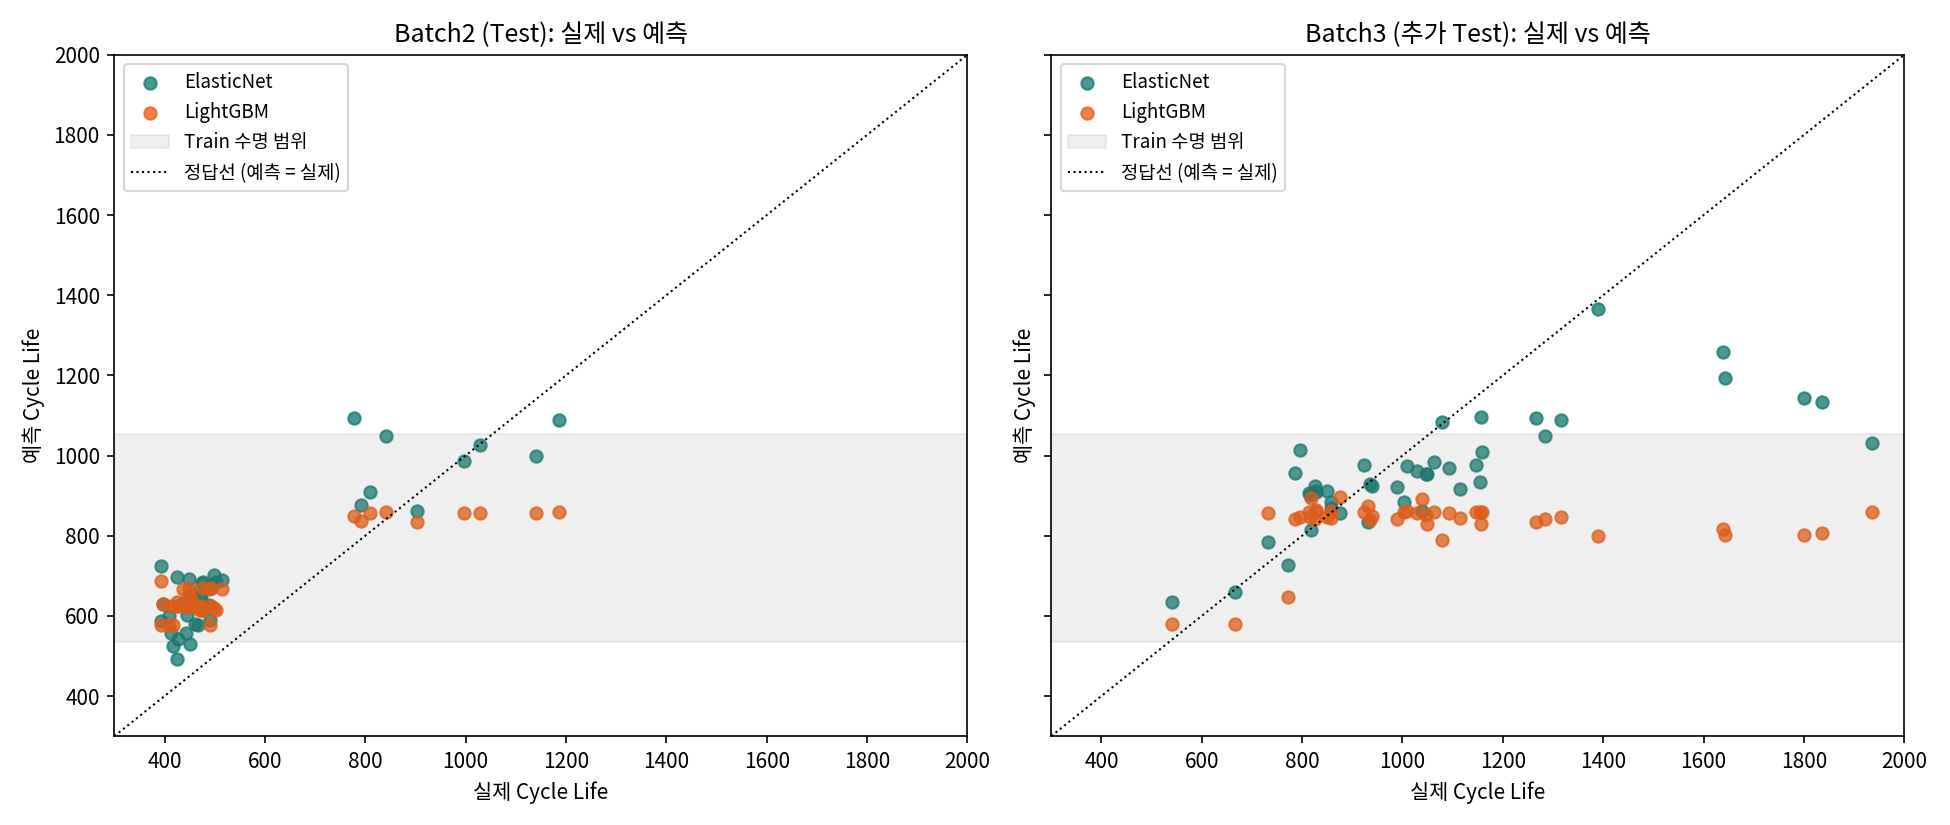

In [7]:
display(pd.read_csv(RES / 'diag_prediction_range.csv'))
display(Image(str(RES / 'figures' / 'diag_extrapolation.png'), width=900))

- LightGBM 예측은 Batch3에서 895, Batch2에서 859를 넘지 못함 → Train 수명 범위 밖(1,000 이상) 셀을 모두 짧게 예측
- 같은 문제가 RandomForest·XGBoost·KNN·SVR에서도 나타남 (Batch3 예측 최대 870~912) → **주변 학습 데이터로 답하는 모델의 공통 한계**
- DAY1 전략의 "범위 밖도 예측하는 선형 모델이 필요하다"는 판단이 데이터로 확인됨

## ⑦ 오류 분석 — Batch2가 왜 30%인가 (`experiments/batch_shift_analysis.py`)

,cells,life_median,dQ_var_median,in_train_range,resid_mean_pct,mape_pct
group,,,,,,
B1 (Train),36,772.5,-3.774,1.000,0.525,8.368
B2 일반,30,451.0,-3.415,0.600,31.814,31.814
B2 newstructure,9,904.0,-4.278,0.333,16.905,17.861
B3 (newstructure),44,1005.5,-4.152,0.523,1.000,12.289


,policy_base,group,size,mean
0,4.8C(80%)-4.8C,B1 (Train),2,753.0
1,4.8C(80%)-4.8C,B2 newstructure,3,871.7
2,4.8C(80%)-4.8C,B2 일반,5,483.6
3,4.8C(80%)-4.8C,B3 (newstructure),6,1564.2
4,5.2C(58%)-4C,B2 newstructure,3,961.7
5,5.2C(58%)-4C,B2 일반,4,477.8
6,5.6C(26%)-4.5C,B2 newstructure,3,991.3
7,5.6C(26%)-4.5C,B2 일반,6,448.5
8,6C(60%)-3C,B1 (Train),2,744.0
9,6C(60%)-3C,B2 일반,2,400.0


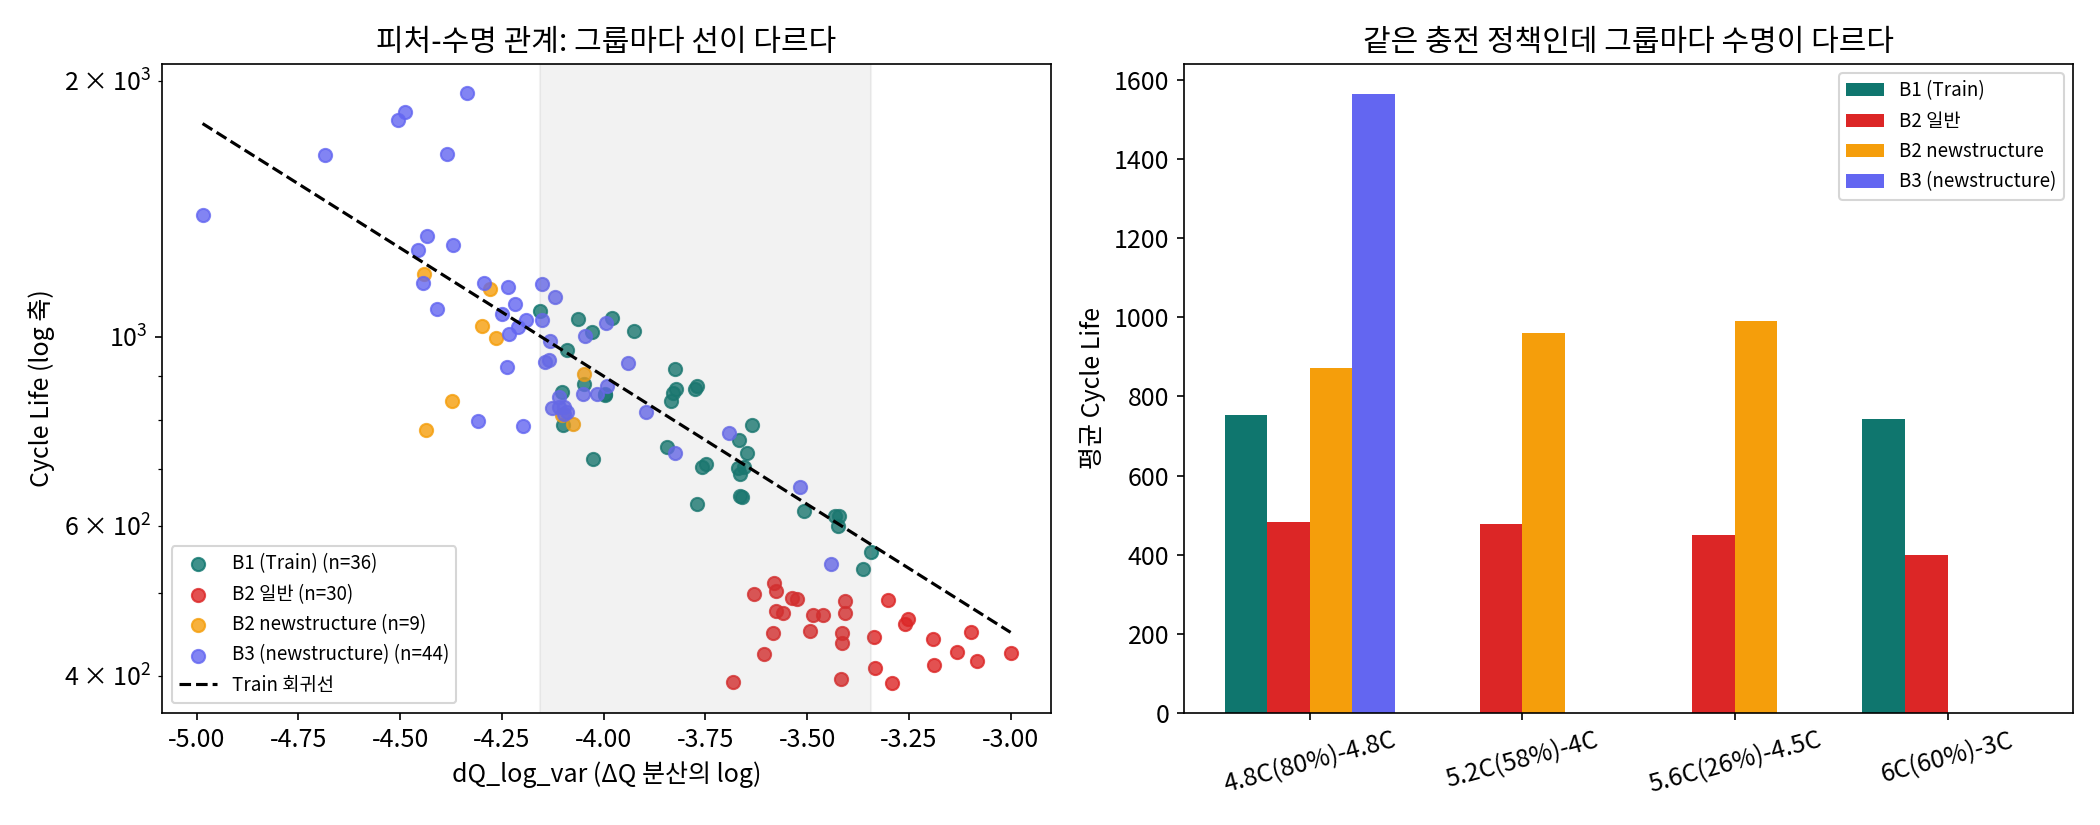

In [8]:
display(pd.read_csv(RES / 'batch_shift_summary.csv', index_col=0))
display(pd.read_csv(RES / 'batch_shift_same_policy.csv'))
display(Image(str(RES / 'figures' / 'batch_shift.png'), width=900))

In [9]:
pred = pd.read_csv(RES / 'predictions.csv', index_col=0)
pred = pred[pred.model == FINAL_MODEL].copy()
pred['오차(%)'] = (pred.pred - pred.cycle_life) / pred.cycle_life * 100
pred['|오차|'] = pred['오차(%)'].abs()
for s in ['Test (Batch2)', 'Test (Batch3)']:
    d = pred[pred.split == s]
    print(f"{s}: 길게 예측한 비율 {(d['오차(%)'] > 0).mean():.0%}")
    display(d.sort_values('|오차|', ascending=False).head(5)[['cycle_life', 'pred', '오차(%)']].round(1))

Test (Batch2): 길게 예측한 비율 95%


,cycle_life,pred,오차(%)
cell_id,,,
b2_c06,393.0,723.1,84.0
b2_c02,424.0,688.8,62.5
b2_c15,396.0,609.9,54.0
b2_c07,777.0,1173.9,51.1
b2_c18,449.0,678.3,51.1


Test (Batch3): 길게 예측한 비율 48%


,cycle_life,pred,오차(%)
cell_id,,,
b3_c38,1935.0,1100.6,-43.1
b3_c40,796.0,1081.8,35.9
b3_c07,1836.0,1212.5,-34.0
b3_c45,1801.0,1226.6,-31.9
b3_c42,1642.0,1135.3,-30.9


- Batch2 일반 셀 30개는 같은 `dQ_log_var` 값에서 Batch1보다 수명이 약 30% 짧음 (Train 회귀선 대비 잔차 +31.8%, 전부 같은 방향)
- 같은 충전 정책도 배치마다 수명이 다름 (4.8C(80%)-4.8C: Batch1 753 / Batch2 일반 484 / Batch3 1,564)
- Batch3는 Train 회귀선을 거의 그대로 따름 → **ΔQ-수명 관계는 일반화되지만, Batch2 일반 셀에서만 깨짐**
- 결론: Batch2 오차는 모델이 아니라 **배치(실험 조건) 차이** 문제. 어떤 모델도 Batch2를 29% 아래로 못 내림
- 개선 방향: 새 배치마다 소량의 수명 데이터로 재보정, 배치 조건 메타데이터 확보 (자세한 내용은 README)